In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
RANDOM_STATE = 42
MODEL_DIR = "/Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts"
os.makedirs(MODEL_DIR, exist_ok=True)

In [3]:
from dotenv import load_dotenv

In [4]:
load_dotenv()

True

In [5]:
# Load Loan Data (Chuncked)
DATA_PATH = "/Users/dr/Documents/GitHub/MBS_RiskManagement/extracted_data/regression_data.csv"

def load_loans(path, chunksize=500_000):
    chunks = []
    for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False,
                             parse_dates=['Monthly Reporting Period', 'First Payment Date']):
        chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True)

print("Loading loans...")
df = load_loans(DATA_PATH)
print(f"Raw shape: {df.shape}")

Loading loans...
Raw shape: (20323122, 21)


In [6]:
# Basic Cleaning
df = df.rename(columns={'Monthly Reporting Period': 'Current_Period'})
df = df.assign(
    First_Payment_Date=pd.to_datetime(df['First Payment Date'], errors='coerce'),
    Current_Period=pd.to_datetime(df['Current_Period'], errors='coerce')
)
df = df.dropna(subset=['First_Payment_Date', 'Current_Period']).copy()

df['Orig_Quarter'] = df['First_Payment_Date'].dt.to_period('Q')
df['Current_Quarter'] = df['Current_Period'].dt.to_period('Q')

In [7]:
from fredapi import Fred

In [8]:
# Macro Data - Quarter-End Alignment
fred = Fred(api_key=os.getenv("FRED_API_KEY"))
series = ['UNRATE', 'MORTGAGE30US', 'FEDFUNDS', 'SPCS20RSA', 'USREC']

macro_raw = {
    s: fred.get_series(s, start='2013-01-01', end='2025-12-31')
    for s in series
}

quarter_ends = pd.date_range('2013-03-31', '2025-12-31', freq='QE')
macro_qtr = pd.DataFrame(index=quarter_ends)

for s, ser in macro_raw.items():
    macro_qtr[s] = ser.resample('QE').agg('max' if s == 'USREC' else 'last')

macro_qtr = macro_qtr.ffill()
macro_qtr['HPI_YoY'] = macro_qtr['SPCS20RSA'].pct_change(4)
macro_qtr.index = macro_qtr.index.to_period('Q')
macro_qtr = macro_qtr.reset_index().rename(columns={'index': 'quarter'})

# Align loan quarters to quarter-end
df['Orig_Quarter_QE'] = pd.PeriodIndex(df['Orig_Quarter']).to_timestamp('Q').to_period('Q')
df['Current_Quarter_QE'] = pd.PeriodIndex(df['Current_Quarter']).to_timestamp('Q').to_period('Q')

# Merge
df = df.merge(macro_qtr.add_suffix('_orig'), left_on='Orig_Quarter_QE', right_on='quarter_orig', how='left')
df = df.merge(macro_qtr.add_suffix('_curr'), left_on='Current_Quarter_QE', right_on='quarter_curr', how='left')
df = df.dropna(subset=[c for c in df.columns if c.endswith('_orig') or c.endswith('_curr')])

print(f"After macro merge: {df.shape[0]:,} rows")

After macro merge: 20,323,119 rows


In [9]:
from sklearn.preprocessing import OneHotEncoder

In [10]:
# Feature Engineering
def engineer_features(df_):
    d = df_.copy()
    
    # Core
    d['Credit_Score'] = d['Credit Score'].clip(lower=300, upper=850)
    d['LTV'] = d['Original Loan-to-Value (LTV)'].clip(upper=150)
    d['DTI'] = d['Original Debt-to-Income (DTI) Ratio'].replace(999, np.nan)
    d['Original_Interest_Rate'] = d['Original Interest Rate']

    # Current state – safe only
    d['Rate_Spread'] = d['Current Interest Rate'] - d['Original Interest Rate']
    
    # Safe seasoning features (always available)
    d['Months_Remaining_Ratio'] = (d['Original Loan Term'] - d['Loan Age']) / d['Original Loan Term']
    d['Months_Remaining_Ratio'] = d['Months_Remaining_Ratio'].clip(lower=0, upper=1)
    d['Loan_Age_Yrs'] = (d['Loan Age'] / 12).clip(upper=30)

    # Risk flags
    d['High_DTI'] = (d['DTI'] > 45).astype(int)
    d['High_LTV'] = (d['LTV'] > 95).astype(int)
    d['Low_FICO'] = (d['Credit_Score'] < 660).astype(int)
    d['In_Negative_Equity'] = (d['Estimated Loan-to-Value (ELTV)'] > 100).astype(int)

    # Macro at origination only
    d['Mortgage_Rate_Orig'] = d['MORTGAGE30US_orig']
    d['Unemp_Rate_Orig']     = d['UNRATE_orig']
    d['HPI_YoY_Orig']        = d['HPI_YoY_orig']
    d['FedFunds_Orig']       = d['FEDFUNDS_orig']
    d['In_Recession_Orig']   = d['USREC_orig'].astype(int)

    # Interactions
    d['High_DTI_x_High_Rate'] = (d['High_DTI'] & (d['Mortgage_Rate_Orig'] > 4.5)).astype(int)
    d['NegEq_x_HPI_Drop']     = d['In_Negative_Equity'] * (d['HPI_YoY_Orig'] < -0.05).astype(int)

    # Categorical
    d['Occupancy_Enc'] = d['Occupancy Status'].fillna('Missing')
    d['Num_Borrowers_Cat'] = d['Number of Borrowers'].astype(str)

    # Judicial state
    judicial_states = ['FL','NY','NJ','IL','OH','PA','CT','DE','IN','KS','KY','LA','ME','MD','MA','MS','NE','NM','ND','OK','SC','VT','WV','WI']
    d['Is_Judicial'] = d['Property State'].isin(judicial_states).astype(int)

    return d

# Apply
df = engineer_features(df)
print("Feature engineering completed")

Feature engineering completed


In [11]:
# Feature List
features = [
    # Core
    'Credit_Score', 'LTV', 'DTI', 'Original_Interest_Rate',
    #'Rate_Spread', 
    'Months_Remaining_Ratio', 'Loan_Age_Yrs',
    
    # Flags
    'High_DTI', 'High_LTV', 'Low_FICO', 'In_Negative_Equity',
    
    # Macro at origination
    'Mortgage_Rate_Orig', 'Unemp_Rate_Orig', 'HPI_YoY_Orig',
    'FedFunds_Orig', 'In_Recession_Orig',
    
    # Interactions
    'High_DTI_x_High_Rate', 'NegEq_x_HPI_Drop',
    
    # Categorical (will be one-hot)
    'Occupancy_Enc', 'Num_Borrowers_Cat', 'Is_Judicial'
]

# Now this will work perfectly
X = df[features].copy()
y = df['Default'].astype(int)

print(f"X shape: {X.shape}")
print(f"Features used ({len(features)}): {features}")

X shape: (20323119, 20)
Features used (20): ['Credit_Score', 'LTV', 'DTI', 'Original_Interest_Rate', 'Months_Remaining_Ratio', 'Loan_Age_Yrs', 'High_DTI', 'High_LTV', 'Low_FICO', 'In_Negative_Equity', 'Mortgage_Rate_Orig', 'Unemp_Rate_Orig', 'HPI_YoY_Orig', 'FedFunds_Orig', 'In_Recession_Orig', 'High_DTI_x_High_Rate', 'NegEq_x_HPI_Drop', 'Occupancy_Enc', 'Num_Borrowers_Cat', 'Is_Judicial']


In [12]:
# Temporal Splits
cutoff_valid = '2024-01-01'
cutoff_test  = '2024-07-01'  # Mid-2024 → ensures test is truly future

train_mask = df['Current_Period'] < cutoff_valid
valid_mask = (df['Current_Period'] >= cutoff_valid) & (df['Current_Period'] < cutoff_test)
test_mask  = df['Current_Period'] >= cutoff_test

X_train, y_train = X[train_mask], y[train_mask]
X_valid, y_valid = X[valid_mask], y[valid_mask]
X_test , y_test  = X[test_mask] , y[test_mask]

print(f"Train {len(X_train):,} (up to 2023)  "
      f"Validation {len(X_valid):,} (2024 H1)  "
      f"Test {len(X_test):,} (2024 H2+)")

Train 7,868,559 (up to 2023)  Validation 294,635 (2024 H1)  Test 12,159,925 (2024 H2+)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [14]:
# Pre-processing (Numeric / Categorical)
num_cols = [c for c in features if c not in ['Occupancy_Enc', 'Num_Borrowers_Cat']]
cat_cols = ['Occupancy_Enc', 'Num_Borrowers_Cat']

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

In [ ]:
# Model + Hyper-Search

print("Starting model training pipeline...")

# ————————————————————————
# SAMPLE FOR FAST HYPERPARAM TUNING
# ————————————————————————
sample_size = 100_000
print(f"\nSampling {sample_size:,} rows from train set (stratified)...")
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train,
    train_size=sample_size,
    stratify=y_train,
    random_state=RANDOM_STATE
)
print(f"Sample default rate: {y_train_sample.mean():.4%} (vs full: {y_train.mean():.4%})")

# ————————————————————————
# GRID SEARCH ON SAMPLE
# ————————————————————————
logreg = LogisticRegression(
    solver='lbfgs',              # ← fastest + always converges
    penalty='l2',                # lbfgs doesn't support elasticnet anyway
    # C=best_C,                  
    max_iter=5000,               # lbfgs almost never needs more than 1000
    tol=1e-6,
    class_weight=None,           # ← remove balanced weights
    random_state=RANDOM_STATE,
    n_jobs=-1,                   # still parallel (multi-threaded, not multi-process)
    warm_start=False
)

pipe = Pipeline([
    ('prep', preprocess),
    ('clf', logreg)
])

param_grid = {
    'clf__C': np.logspace(-3, 1, 5)  # 0.001, 0.01, 0.1, 1.0, 10.0
}

tscv = TimeSeriesSplit(n_splits=3)

grid = GridSearchCV(
    pipe, param_grid,
    scoring='roc_auc',
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

print(f"\nFitting GridSearchCV on {sample_size:,} samples...")
grid.fit(X_train_sample, y_train_sample)

best_C = grid.best_params_['clf__C']
print(f"Best C (on sample) = {best_C:.6f} | CV AUC = {grid.best_score_:.4%}")

Starting model training pipeline...

Sampling 100,000 rows from train set (stratified)...
Sample default rate: 0.3750% (vs full: 0.3751%)

Fitting GridSearchCV on 100,000 samples...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best C (on sample) = 1.000000 | CV AUC = 87.4307%


In [17]:
# Final Model 
print(f"\nRefitting final model on FULL train set ({len(X_train):,} rows) with C={best_C:.6f}...")

final_clf = LogisticRegression(
    solver='lbfgs',              # ← fastest + always converges
    penalty='l2',                # lbfgs doesn't support elasticnet anyway
    C=best_C,                   
    max_iter=5000,               # lbfgs almost never needs more than 1000
    tol=1e-6,
    class_weight=None,           
    random_state=RANDOM_STATE,
    n_jobs=-1,                   # still parallel (multi-threaded, not multi-process)
    warm_start=False
)

final_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', final_clf)
])

final_pipe.fit(X_train, y_train)


Refitting final model on FULL train set (7,868,559 rows) with C=1.000000...


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
from sklearn.calibration import CalibratedClassifierCV

In [19]:
# Calibration on Validation Set
print(f"\nCalibrating on validation set ({len(X_valid):,} rows)...")
calibrated_model = CalibratedClassifierCV(final_pipe, method='sigmoid', cv=5, n_jobs=1)
calibrated_model.fit(X_valid, y_valid)
print("Calibration complete.")


Calibrating on validation set (294,635 rows)...
Calibration complete.


In [20]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, average_precision_score

In [21]:
# Final Evaluation (on Test Set)

print("\n" + "="*50)
print("FINAL EVALUATION ON TEST SET (2024 H2+)".center(50))
print("="*50)

# Predict probabilities
y_prob = calibrated_model.predict_proba(X_test)[:, 1]

# Top 5% risk threshold (dynamic)
threshold_95 = np.percentile(y_prob, 95)
y_pred_top5 = (y_prob >= threshold_95).astype(int)

# Metrics
auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
precision_5pct = precision_score(y_test, y_pred_top5)
recall_5pct = recall_score(y_test, y_pred_top5)

# Print
print(f"Test Period        : 2024-07-01 to {df['Current_Period'].max().strftime('%Y-%m-%d')}")
print(f"Test Size          : {len(X_test):,} loans")
print(f"Default Rate       : {y_test.mean():.4%}")
print(f"ROC-AUC            : {auc:.4%}")
print(f"PR-AUC             : {pr_auc:.4%}")
print(f"Top-5% Precision   : {precision_5pct:.4%}")
print(f"Top-5% Recall      : {recall_5pct:.4%}")
print(f"Top-5% Threshold   : {threshold_95:.6f}")

# Optional: Save metrics
test_metrics = {
    'test_period': '2024_H2',
    'n_test': len(X_test),
    'default_rate': y_test.mean(),
    'roc_auc': auc,
    'pr_auc': pr_auc,
    'precision_5pct': precision_5pct,
    'recall_5pct': recall_5pct,
    'threshold_95': threshold_95
}

metrics_path = os.path.join(MODEL_DIR, "test_metrics.json")
pd.Series(test_metrics).to_json(metrics_path)
print(f"\nMetrics saved to: {metrics_path}")


     FINAL EVALUATION ON TEST SET (2024 H2+)      
Test Period        : 2024-07-01 to 2025-03-01
Test Size          : 12,159,925 loans
Default Rate       : 1.4785%
ROC-AUC            : 71.5556%
PR-AUC             : 4.4044%
Top-5% Precision   : 6.0204%
Top-5% Recall      : 20.3596%
Top-5% Threshold   : 0.026517

Metrics saved to: /Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts/test_metrics.json


In [22]:
# Walk-Forward Backtest (2020–2024) Using FINAL Model
print("\n" + "="*60)
print("WALK-FORWARD BACKTEST (2020–2024) – USING FINAL MODEL".center(60))
print("="*60)

# Use the FINAL calibrated model (already trained on 2014–2023)
final_model = calibrated_model  # ← from earlier

wf_results = []
years = range(2020, 2025)

for test_year in years:
    test_start = f'{test_year}-01-01'
    test_end   = f'{test_year + 1}-01-01'
    
    # Define test period
    test_mask = (df['Current_Period'] >= test_start) & (df['Current_Period'] < test_end)
    
    if test_mask.sum() < 1000:
        print(f"Skipping {test_year}: only {test_mask.sum()} loans")
        continue
    
    X_te, y_te = X[test_mask], y[test_mask]
    
    # Predict with FINAL model (no retraining!)
    y_prob = final_model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)
    
    wf_results.append({
        'Year': test_year,
        'AUC': auc,
        'N_Test': len(y_te),
        'Default_Rate': y_te.mean()
    })
    
    print(f"{test_year}: AUC = {auc:.4%} | N = {len(y_te):,} | Default = {y_te.mean():.4%}")

# Final table
wf_df = pd.DataFrame(wf_results).set_index('Year')
print("\n" + "="*60)
print("WALK-FORWARD SUMMARY")
print("="*60)
print(wf_df.round(4))

# Save
wf_path = os.path.join(MODEL_DIR, "walk_forward_backtest.csv")
wf_df.to_csv(wf_path)
print(f"\nResults saved to: {wf_path}")


   WALK-FORWARD BACKTEST (2020–2024) – USING FINAL MODEL    
2020: AUC = 97.3327% | N = 2,131,851 | Default = 0.0715%
2021: AUC = 97.1751% | N = 2,208,925 | Default = 0.0883%
2022: AUC = 97.3485% | N = 911,350 | Default = 0.1566%
2023: AUC = 96.7459% | N = 556,693 | Default = 0.3510%
2024: AUC = 97.6625% | N = 662,545 | Default = 0.3668%

WALK-FORWARD SUMMARY
         AUC   N_Test  Default_Rate
Year                               
2020  0.9733  2131851        0.0007
2021  0.9718  2208925        0.0009
2022  0.9735   911350        0.0016
2023  0.9675   556693        0.0035
2024  0.9766   662545        0.0037

Results saved to: /Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts/walk_forward_backtest.csv


In [28]:
from sklearn.metrics import roc_curve, precision_recall_curve

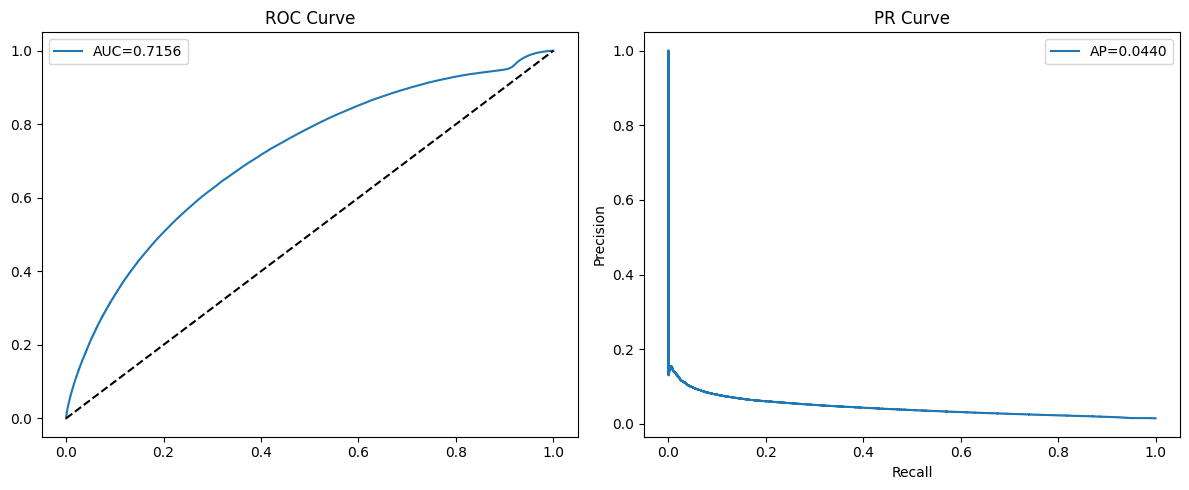

In [29]:
#Curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0,1],[0,1],'k--'); plt.title("ROC Curve"); plt.legend()

plt.subplot(1,2,2)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision, label=f"AP={average_precision_score(y_test, y_prob):.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR Curve"); plt.legend()
plt.tight_layout(); plt.show()

In [23]:
import shap

In [24]:
import matplotlib.pyplot as plt


                SHAP ANALYSIS (100 k sample)                
   Sampled 100,000 loans
   Transformed to 27 features
   27 features (with one-hot)
   Computing SHAP values (LinearExplainer)...
   SHAP computed: (100000, 27)


/opt/anaconda3/lib/python3.12/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


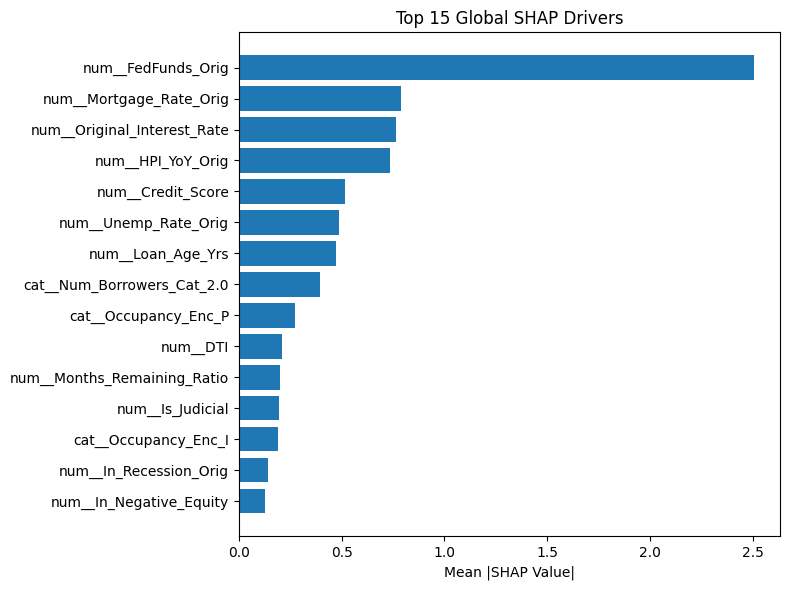

   Saved: /Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts/shap_global_bar.png
   Plotting beeswarm...


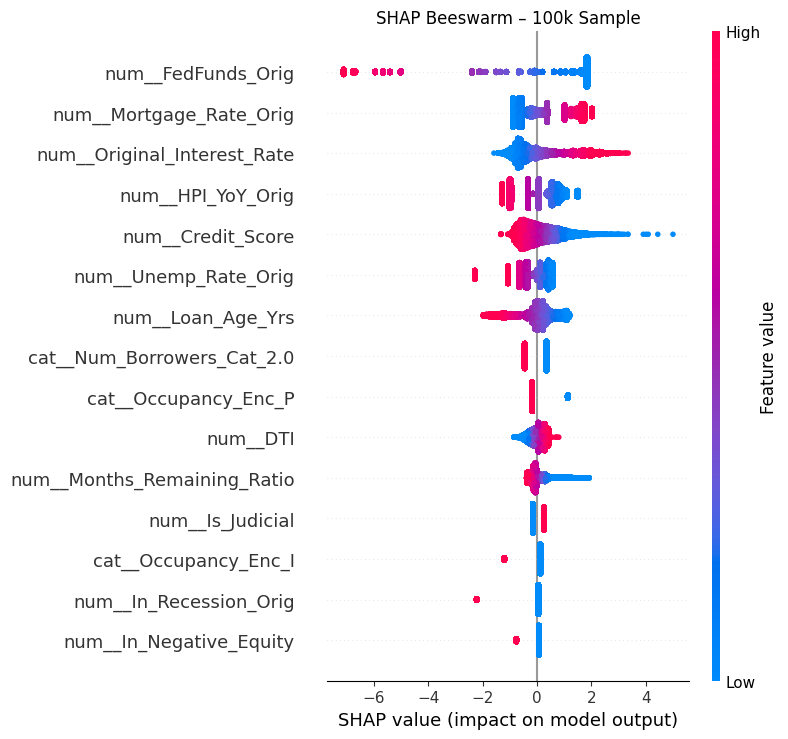

   Saved: /Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts/shap_beeswarm.png

Top 10 SHAP Drivers:
                        feature  mean_abs_shap
13           num__FedFunds_Orig         2.5081
10      num__Mortgage_Rate_Orig         0.7895
3   num__Original_Interest_Rate         0.7658
12            num__HPI_YoY_Orig         0.7368
0             num__Credit_Score         0.5184
11         num__Unemp_Rate_Orig         0.4866
5             num__Loan_Age_Yrs         0.4714
22   cat__Num_Borrowers_Cat_2.0         0.3940
19         cat__Occupancy_Enc_P         0.2744
2                      num__DTI         0.2101
   Table saved: /Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts/shap_top_features.csv


In [25]:
# SHAP Analysis

print("\n" + "="*60)
print("SHAP ANALYSIS (100 k sample)".center(60))
print("="*60)

# ------------------------------------------------------------------
# Sample 100k rows from test set
# ------------------------------------------------------------------
sample_size = 100_000
X_test_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE).copy()
print(f"   Sampled {len(X_test_sample):,} loans")

# ------------------------------------------------------------------
# Get the original Pipeline from CalibratedClassifierCV
# ------------------------------------------------------------------
# This is the original Pipeline you passed to CalibratedClassifierCV
original_pipeline = calibrated_model.estimator  # ← This is your Pipeline('prep', 'clf')

# Extract components
preprocess = original_pipeline.named_steps['prep']
logreg_clf = original_pipeline.named_steps['clf']

# ------------------------------------------------------------------
# Transform sample using the SAME preprocessing
# ------------------------------------------------------------------
X_preproc = preprocess.transform(X_test_sample)
print(f"   Transformed to {X_preproc.shape[1]} features")

# ------------------------------------------------------------------
# Get feature names after one-hot encoding
# ------------------------------------------------------------------
feature_names = preprocess.get_feature_names_out()
print(f"   {len(feature_names)} features (with one-hot)")

# ------------------------------------------------------------------
# Compute SHAP values using the LogisticRegression model
# ------------------------------------------------------------------
print("   Computing SHAP values (LinearExplainer)...")
explainer = shap.LinearExplainer(
    logreg_clf,                     # the actual LogisticRegression
    X_preproc,
    feature_perturbation="interventional"
)
shap_vals = explainer.shap_values(X_preproc)
print(f"   SHAP computed: {shap_vals.shape}")

# ------------------------------------------------------------------
# Global importance
# ------------------------------------------------------------------
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top_n = 15
idx = np.argsort(-mean_abs_shap)[:top_n]

# ------------------------------------------------------------------
# GLOBAL BAR PLOT
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.barh(np.array(feature_names)[idx][::-1], mean_abs_shap[idx][::-1], color="#1f77b4")
plt.xlabel("Mean |SHAP Value|")
plt.title(f"Top {top_n} Global SHAP Drivers")
plt.tight_layout()
bar_path = os.path.join(MODEL_DIR, "shap_global_bar.png")
plt.savefig(bar_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"   Saved: {bar_path}")

# ------------------------------------------------------------------
# BEESWARM PLOT
# ------------------------------------------------------------------
print("   Plotting beeswarm...")
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals,
    X_preproc,
    feature_names=feature_names,
    max_display=top_n,
    show=False
)
plt.title("SHAP Beeswarm – 100k Sample")
plt.tight_layout()
bee_path = os.path.join(MODEL_DIR, "shap_beeswarm.png")
plt.savefig(bee_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"   Saved: {bee_path}")

# ------------------------------------------------------------------
# TOP 10 TABLE
# ------------------------------------------------------------------
shap_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

print("\nTop 10 SHAP Drivers:")
print(shap_df.head(10).round(4))

# Save
shap_table_path = os.path.join(MODEL_DIR, "shap_top_features.csv")
shap_df.head(50).to_csv(shap_table_path, index=False)
print(f"   Table saved: {shap_table_path}")

In [26]:
import joblib
from datetime import datetime

In [27]:
# Save Final Model & Artifacts

print("\n" + "="*60)
print("SAVING FINAL MODEL & ARTIFACTS".center(60))
print("="*60)

# ------------------------------------------------------------------
# Final prediction threshold (Top 5% risk)
# ------------------------------------------------------------------
y_prob = calibrated_model.predict_proba(X_test)[:, 1]
threshold_95 = np.percentile(y_prob, 95)

# ------------------------------------------------------------------
# Final test metrics (2024 H2)
# ------------------------------------------------------------------

auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
y_pred_top5 = (y_prob >= threshold_95).astype(int)
precision_5pct = precision_score(y_test, y_pred_top5)
recall_5pct = recall_score(y_test, y_pred_top5)

# ------------------------------------------------------------------
# Artifacts dictionary
# ------------------------------------------------------------------
artifacts = {
    # Core model
    "pipeline": calibrated_model,                    # Final calibrated model
    "features": features,                            # Original feature list
    "preprocessing": calibrated_model.estimator.named_steps['prep'],  # For inference
    
    # Deployment
    "threshold_95": float(threshold_95),             # Top 5% cutoff
    "default_rate_test": float(y_test.mean()),       # Baseline risk
    
    # Performance
    "metrics": {
        "test_period": "2024_H2",
        "n_test": int(len(X_test)),
        "roc_auc": float(auc),
        "pr_auc": float(pr_auc),
        "precision_5pct": float(precision_5pct),
        "recall_5pct": float(recall_5pct),
        "threshold_95": float(threshold_95)
    },
    
    # Metadata
    "model_version": "v1.0",
    "train_period": "2014-01-01 to 2023-12-31",
    "valid_period": "2024-01-01 to 2024-06-30",
    "test_period": "2024-07-01 to 2024-12-31",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S EST"),
    "author": "Your Name",
    "description": "Logistic Regression + SHAP + Calibration (No Look-Ahead)"
}

# ------------------------------------------------------------------
# Save to disk
# ------------------------------------------------------------------
model_filename = "final_calibrated_pipeline.pkl"
model_path = os.path.join(MODEL_DIR, model_filename)
joblib.dump(artifacts, model_path)

print(f"Model saved: {model_path}")
print(f"   → Size: {os.path.getsize(model_path) / 1e6:.1f} MB")
print(f"   → Threshold (95th %): {threshold_95:.6f}")
print(f"   → Test AUC: {auc:.4%} | Precision@5%: {precision_5pct:.4%}")

# ------------------------------------------------------------------
# Save human-readable summary
# ------------------------------------------------------------------
summary = {
    "Model": "Calibrated Logistic Regression",
    "Train Period": artifacts["train_period"],
    "Test Period": artifacts["test_period"],
    "Test AUC": f"{auc:.4%}",
    "Top-5% Precision": f"{precision_5pct:.4%}",
    "Top-5% Recall": f"{recall_5pct:.4%}",
    "Threshold": f"{threshold_95:.6f}",
    "Features": len(features),
    "Saved": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

summary_df = pd.DataFrame([summary])
summary_path = os.path.join(MODEL_DIR, "model_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"Summary saved: {summary_path}")


               SAVING FINAL MODEL & ARTIFACTS               
Model saved: /Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts/final_calibrated_pipeline.pkl
   → Size: 0.0 MB
   → Threshold (95th %): 0.026517
   → Test AUC: 71.5556% | Precision@5%: 6.0204%
Summary saved: /Users/dr/Documents/GitHub/MBS_RiskManagement/regression_codes/model_artifacts/model_summary.csv
